# Step 3 — Preprocessing & Train/Test Strategy
### gametheory-sweetcrete

The bridge between EDA and modeling. With only ~178 rows, **how** we split and scale
the data determines whether the eventual R² is trustworthy or just luck. This notebook:

1. Loads the 5 selected features and the target via `src/preprocessing.py`
2. Shows why the features need scaling (they live on wildly different numeric scales)
3. Makes a **stratified** train/test split (every PCC level represented in both)
4. Defines a **leak-proof scaling pipeline** + **repeated k-fold cross-validation**
5. Runs a quick baseline to confirm the plumbing is sound

Everything here lives in `src/preprocessing.py` so Step 4 (modeling) reuses the *exact*
same split, scaler, and CV.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# locate repo root + import our preprocessing module
p = Path.cwd()
while not (p / "src").exists() and p != p.parent:
    p = p.parent
ROOT = p
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))

from preprocessing import (load_xy, get_split, build_pipeline, cv_strategy,
                           SELECTED_FEATURES, TARGET)

X, y, _ = load_xy()
print("Feature matrix:", X.shape, "| target:", y.shape)
X.describe().round(2)

Feature matrix: (178, 5) | target: (178,)


,Age_days,Cement_lbs,PCC_Fraction,WaterCement_Ratio,CoarseAgg_lbs
count,178.00,178.00,178.00,178.00,178.00
mean,36.26,75.09,0.05,0.59,227.24
std,32.96,21.46,0.03,0.14,23.62
min,1.00,46.98,0.00,0.44,214.49
25%,7.00,61.07,0.01,0.47,221.41
50%,28.00,75.16,0.04,0.55,221.41
75%,56.00,85.33,0.07,0.67,221.41
max,90.00,129.18,0.10,0.87,304.44


## 1. Why scaling is needed
Look at the raw feature ranges below — `Cement_lbs` and `CoarseAgg_lbs` are in the
hundreds while `PCC_Fraction` and `WaterCement_Ratio` are below 1. Distance- and
gradient-based models (SVR, KNN, linear) would be dominated by the large-magnitude
features unless we standardize. Tree models don't care, but standardizing is harmless
for them — so one consistent pipeline works for all.

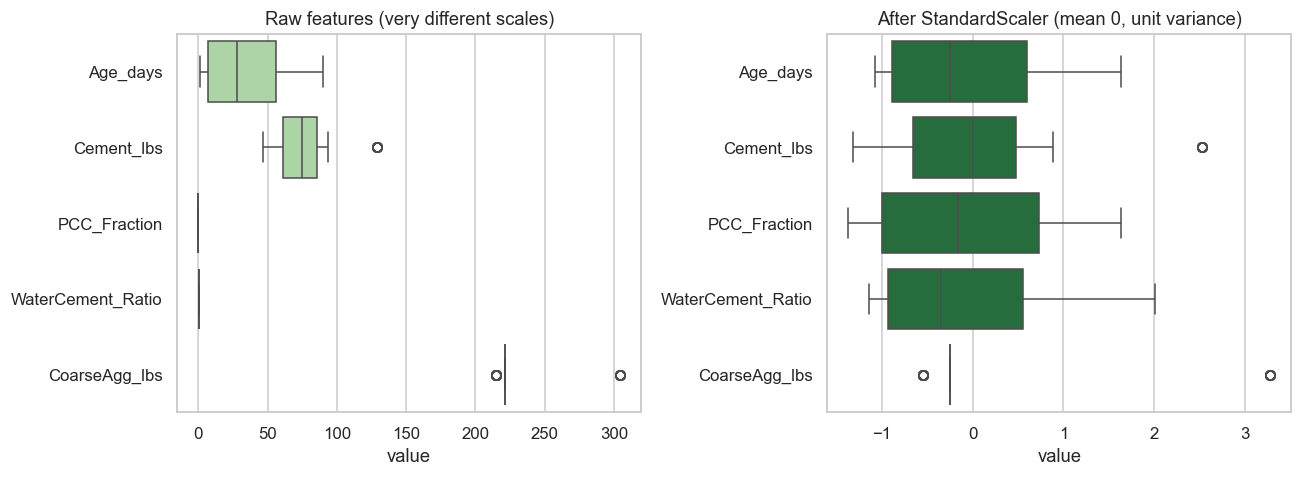

In [2]:
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=X, orient="h", ax=axes[0], color="#a6dba0")
axes[0].set_title("Raw features (very different scales)")
sns.boxplot(data=X_scaled, orient="h", ax=axes[1], color="#1b7837")
axes[1].set_title("After StandardScaler (mean 0, unit variance)")
for a in axes: a.set_xlabel("value")
plt.tight_layout(); plt.savefig(FIG / "preprocessing_scaling.png", bbox_inches="tight")
plt.show()

## 2. Stratified train/test split
We hold out 20% as a final test set, **stratified by PCC replacement level** so every
level (0%–50%) appears in both train and test — important on a small grid dataset.
The split is saved to `data/processed/splits/` for full reproducibility.

In [3]:
X_train, X_test, y_train, y_test = get_split()
print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")

SPLITS = ROOT / "data" / "processed" / "splits"; SPLITS.mkdir(parents=True, exist_ok=True)
X_train.to_csv(SPLITS / "X_train.csv", index=False)
X_test.to_csv(SPLITS / "X_test.csv", index=False)
y_train.to_csv(SPLITS / "y_train.csv", index=False)
y_test.to_csv(SPLITS / "y_test.csv", index=False)
print("Saved splits ->", SPLITS)

# sanity: PCC levels present in both splits (via the cleaned frame ordering)
print("\nTrain target mean: %.2f MPa | Test target mean: %.2f MPa"
      % (y_train.mean(), y_test.mean()))

Train: 142 rows   Test: 36 rows
Saved splits -> /Users/rohanshrestha/Documents/gametheory-sweetcrete/data/processed/splits

Train target mean: 27.46 MPa | Test target mean: 25.54 MPa


## 3. Leak-proof scaling + cross-validation
The scaler is wrapped **inside** a pipeline (`build_pipeline`). When we cross-validate,
the scaler is re-fit on each fold's training portion only — the validation rows never
leak into the scaling statistics. CV is **5-fold repeated 3×** for a stable estimate.

In [4]:
cv = cv_strategy()

# Baseline A: Ridge linear regression (a sensible floor)
ridge = build_pipeline(Ridge(alpha=1.0))
r2_ridge = cross_val_score(ridge, X_train, y_train, cv=cv, scoring="r2")

# Baseline B: untuned Random Forest (a strong non-linear reference)
rf = build_pipeline(RandomForestRegressor(n_estimators=300, random_state=42))
r2_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring="r2")

print("Cross-validated R^2 (train set, 5-fold x3):")
print(f"  Ridge (linear baseline) : {r2_ridge.mean():.3f}  +/- {r2_ridge.std():.3f}")
print(f"  Random Forest (untuned) : {r2_rf.mean():.3f}  +/- {r2_rf.std():.3f}")

Cross-validated R^2 (train set, 5-fold x3):
  Ridge (linear baseline) : 0.577  +/- 0.204
  Random Forest (untuned) : 0.879  +/- 0.064


## Takeaways

- **The pipeline is sound and reproducible.** The same split/scale/CV objects now live in `src/preprocessing.py` for Step 4 to import.
- **There's clear non-linear signal.** The linear baseline lags the Random Forest, confirming strength depends non-linearly on age/PCC — exactly what tree and boosting models capture well.
- **The untuned Random Forest is already in the ~0.9 R² range under honest cross-validation**, so the 0.93 target is realistic once we compare and tune models in Step 4.

**Next:** Step 4 — train and tune multiple models (Linear/Ridge, Random Forest, XGBoost, SVR, KNN), compare them under this CV, and lock in the best one.